In [1]:
import pandas as pd
df = pd.read_csv("lending_club_50k.csv")

status_paid = 1
status_fail = 0

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df = df.reset_index(drop=True)

df = df.sample(frac=0.803,random_state=64)

def encodeLoanStatus(status):
    if status == "Fully Paid": return status_paid
    return status_fail

df["loan_status"] = df["loan_status"].apply(encodeLoanStatus)

df.shape

/var/folders/xf/2m7vn2ds72bfzhbhpfn49fh00000gn/T/ipykernel_23949/3792894940.py:2: DtypeWarning: Columns (59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("lending_club_50k.csv")


(40000, 152)

In [2]:
leakage_columns = [
"total_pymnt",
"total_pymnt_inv",
"total_rec_prncp",
"total_rec_int",
"total_rec_late_fee",
"last_pymnt_amnt",
"out_prncp",
"out_prncp_inv",
"recoveries",
"collection_recovery_fee",
"debt_settlement_flag",
"debt_settlement_flag_date",
"settlement_status",
"settlement_date",
"settlement_amount",
"settlement_percentage",
"settlement_term",
"last_fico_range_high", ## current fice score
"last_fico_range_low", ## current fico score
"last_pymnt_d",
"last_credit_pull_d", ## this was updated after credit was issiued.
"mths_since_recent_bc", # this value is updated after the loan
"mths_since_recent_inq", # this value is updated after the loan
]
print(len(leakage_columns))
df.drop(columns=leakage_columns, inplace=True)
df.shape

23


(40000, 129)

In [3]:
null_columns = df.columns[df.isnull().mean() > 0.4].tolist() # We are removing columns which contain null values more than %40.
df.drop(columns=null_columns, inplace=True)
df.shape

(40000, 76)

In [4]:
# check uniqueness
# by checking uniqueness we can determinine columns which act like Primary KEY(id) or Constant
# these columns have no impact on model , we are removing these columns
unique_counts = df.nunique(dropna=False)
primary_key_or_constant_cols = []
for col in df.columns:
    if (unique_counts[col] == 1 or unique_counts[col] == len(df)):
        primary_key_or_constant_cols.append(col)

print(primary_key_or_constant_cols)

df.drop(columns=primary_key_or_constant_cols, inplace=True)
df.shape

['id', 'pymnt_plan', 'url', 'policy_code', 'hardship_flag', 'disbursement_method']


(40000, 70)

In [5]:
# continue to uniqueness
# some columns contains too much unique value like emp_title and title
# in order to suppress noise we decided to ignore values that have less than %0.01 weight.
# by this way , we would be able to keep values which have significant height like Teacher/Nurse
# and ignore values which have %0.01 weight.
unique_counts = df.nunique(dropna=False).sort_values(ascending=False)

# show columns that contains more than 100 unique categorical values
for col, count in unique_counts.items():
    if df[col].dtype != float and count>100:
        print(f"{col}-{count}")

from collections import Counter

freq_emp_title = Counter(df["emp_title"])
freq_title = Counter(df["title"])
noise_treshold_percentage = 0.001
noise_treshold_value = len(df) * noise_treshold_percentage #for performance
default_value_for_noise="__noise__"

def supprassNoises(value,hash_table):
    if(hash_table[value] < noise_treshold_value): return default_value_for_noise
    return value

df["emp_title"] = df["emp_title"].apply(supprassNoises,hash_table=freq_emp_title)
df["title"] = df["title"].apply(supprassNoises,hash_table=freq_title)

print("\nafter supprassing noises\n")

print(f"emp_title-{df["emp_title"].nunique()}")
print(f"title-{df["title"].nunique()}")

df.drop(columns=["zip_code"], inplace=True) # third one: zip_code can be removed ,an irrelevant column
# in here, last column(earliest_cr_line) is a formatted date column. we will convert it date then number.

# convert the column to datetime
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
# there is another date column in the data
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%Y-%m-%d')

# convert date variables to number
# method -> (Year+1)+Month/13

def encodeDates(date_value):
    return (date_value.year+1)+(date_value.month/13)

df["earliest_cr_line"] = df["earliest_cr_line"].apply(encodeDates)
df["issue_d"] = df["issue_d"].apply(encodeDates)

df.shape

tot_cur_bal-36662
tot_hi_cred_lim-34448
total_bal_ex_mort-32684
total_il_high_credit_limit-27121
revol_bal-23708
emp_title-20045
total_rev_hi_lim-2871
title-2767
tot_coll_amt-2100
total_bc_limit-2020
funded_amnt_inv-1276
funded_amnt-1230
loan_amnt-1230
zip_code-864
mo_sin_old_rev_tl_op-602
earliest_cr_line-590
mo_sin_rcnt_rev_tl_op-156
delinq_amnt-132
mo_sin_rcnt_tl-109

after supprassing noises

emp_title-68
title-24


ValueError: time data "Jul-04" doesn't match format "%b-%Y", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [6]:
# fill na values

def showNullValuesColumnByColumn():
    null_counts = df.isnull().sum()
    null_counts_without_zero = null_counts[null_counts > 0].sort_values(ascending=False)
    print(f"{null_counts_without_zero}\n")

print("null values - before")
showNullValuesColumnByColumn()

df["emp_length"] = df["emp_length"].fillna("0 year")
df["emp_title"] = df["emp_title"].fillna("__title__")

null_avg_cur_bal = df["avg_cur_bal"].isnull().sum()
null_pct_tl_nvr_dlq = df["pct_tl_nvr_dlq"].isnull().sum()
null_revol_util = df["revol_util"].isnull().sum()

print(f"null count :{null_avg_cur_bal} percentage:{null_avg_cur_bal/len(df)}")
print(f"null count :{null_pct_tl_nvr_dlq} percentage:{null_pct_tl_nvr_dlq/len(df)}")
print(f"null count :{null_revol_util} percentage:{null_revol_util/len(df)}\n")

# since these three columns contains very few (<0.0001) null values
# Best way was to fill them with median

def fillNaWithMedian(colName):
    df[colName] = df[colName].fillna(df[colName].median())

fillNaWithMedian("avg_cur_bal")
fillNaWithMedian("pct_tl_nvr_dlq")
fillNaWithMedian("revol_util")

def fillNaWithZero(colName):
    df[colName] = df[colName].fillna(0)

# these three columns have very similar null rates and
# when we inspected them we realised they are sometimes null because
# their linked parent column is 0
# so best approach is filling these null values with 0
temprows = df[df["total_bc_limit"] == 0][["bc_util","percent_bc_gt_75","bc_open_to_buy"]]
print(f"{temprows["bc_util"].value_counts(dropna=False)}\n")
print(f"{temprows["percent_bc_gt_75"].value_counts(dropna=False)}\n")
print(f"{temprows["bc_open_to_buy"].value_counts(dropna=False)}\n")

fillNaWithZero("bc_util")
fillNaWithZero("percent_bc_gt_75")
fillNaWithZero("bc_open_to_buy")

# the column is checked , it holds the info when the first installment account is opened
# when the borrower has never taken a credit before , this values  become null
# so filling with median is suitable
fillNaWithMedian("mo_sin_old_il_acct")

print("null values - after")
showNullValuesColumnByColumn()

# last null column (num_tl_120dpd_2m) will be checked in EDA process
# to determine whether keep the column or not


null values - before
emp_title             2337
emp_length            2165
num_tl_120dpd_2m      1436
mo_sin_old_il_acct    1316
bc_util                404
percent_bc_gt_75       394
bc_open_to_buy         375
revol_util              21
pct_tl_nvr_dlq           7
avg_cur_bal              1
dtype: int64

null count :1 percentage:2.5e-05
null count :7 percentage:0.000175
null count :21 percentage:0.000525

bc_util
NaN    375
0.0     19
Name: count, dtype: int64

percent_bc_gt_75
NaN    394
Name: count, dtype: int64

bc_open_to_buy
NaN    375
0.0     19
Name: count, dtype: int64

null values - after
num_tl_120dpd_2m    1436
dtype: int64



In [7]:
# exploratory data analysis(EDA)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def draw_plot(draw_colum):
    # 1. Filter for relevant loan statuses
    df_f = df
    
    # 2. Setup the side-by-side layout
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- LEFT GRAPH: Total vs Fully Paid ---
    subgrade_order = sorted(df_f[draw_colum].unique())
    
    # Plot 1: Total (Both Paid and Charged Off) - Dark Blue
    sns.countplot(x=draw_colum, data=df_f, ax=ax[0], order=subgrade_order, 
                  color='darkblue', label='Total (Both)')
    
    # Plot 2: Only Fully Paid - Light Blue
    sns.countplot(x=draw_colum, data=df_f[df_f['loan_status'] == status_paid], 
                  ax=ax[0], order=subgrade_order, color='lightblue', label='Fully Paid')
    
    ax[0].set_title('Total vs Fully Paid (Gap = Defaulted)')
    ax[0].legend()
    ax[0].tick_params(axis='x', rotation=45)
    
    # --- RIGHT GRAPH: Default Rate (Charged-off Rate) ---
    rate = df_f.groupby(draw_colum)['loan_status'].apply(lambda x: (x == status_fail).mean()).sort_index()
    sns.barplot(x=rate.index, y=rate.values, ax=ax[1])
    
    ax[1].set_title('Default Rate per Category')
    ax[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

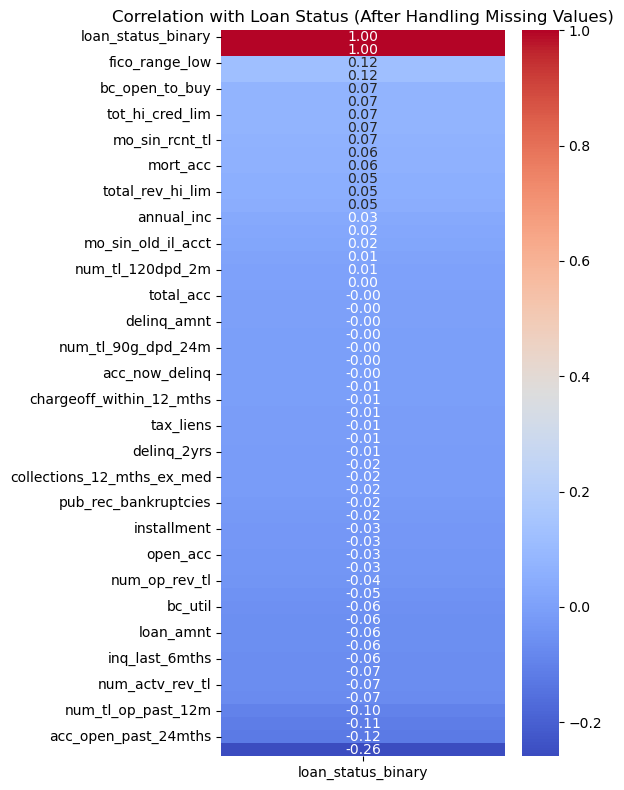

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Copy dataframe
df_combined = df.copy()

# Convert loan_status to binary
# (Default/Charged Off = 1, Fully Paid = 0)
df_combined['loan_status_binary'] = df_combined['loan_status'].apply(
    lambda x: 0 if x == status_fail else 1
)

# Select numeric columns
numeric_df = df_combined.select_dtypes(include=[np.number])

# Handle missing values (median imputation)
numeric_df_filled = numeric_df.fillna(numeric_df.median())

#Compute correlation matrix
corr_matrix = numeric_df_filled.corr()

#Extract correlation with target only
target_corr = corr_matrix[['loan_status_binary']].sort_values(
    by='loan_status_binary',
    ascending=False
)

#Plot heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(
    target_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation with Loan Status (After Handling Missing Values)")
plt.tight_layout()
plt.show()

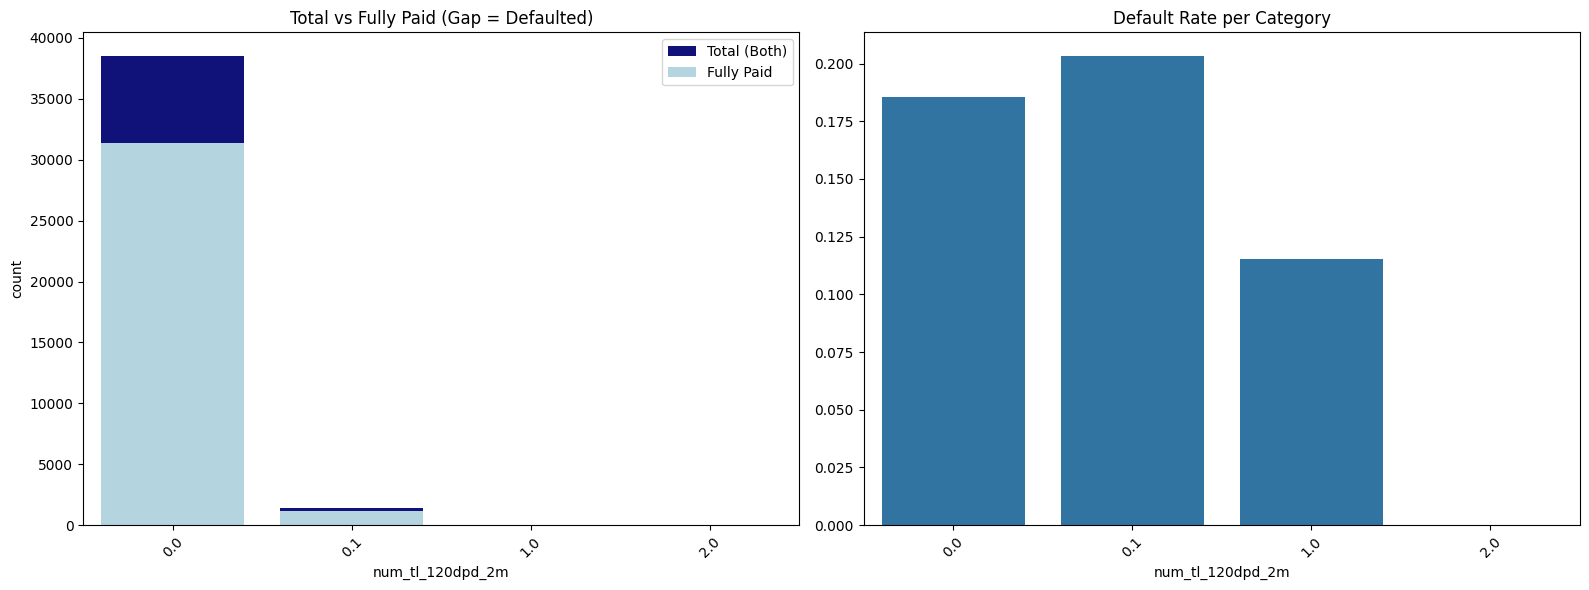

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,7443.0,0.004326,0.027871,0.0,0.0,0.0,0.0,1.0
1,32557.0,0.004282,0.034094,0.0,0.0,0.0,0.0,2.0


In [12]:
df["num_tl_120dpd_2m"] = df["num_tl_120dpd_2m"].fillna(0.1)
draw_plot("num_tl_120dpd_2m")

df.groupby("loan_status")["num_tl_120dpd_2m"].describe()

In [13]:
# overall default rate
print("overall default rate")
print(len(df[df["loan_status"]== status_fail]) / len(df))

# %99.999 values either 0.0 or nan(fillna(0.1)) and their default rate almost as same as overall default rate
# this column can be removed since it has no impact on result.
df.drop(columns=["num_tl_120dpd_2m"], inplace=True)

overall default rate
0.186075


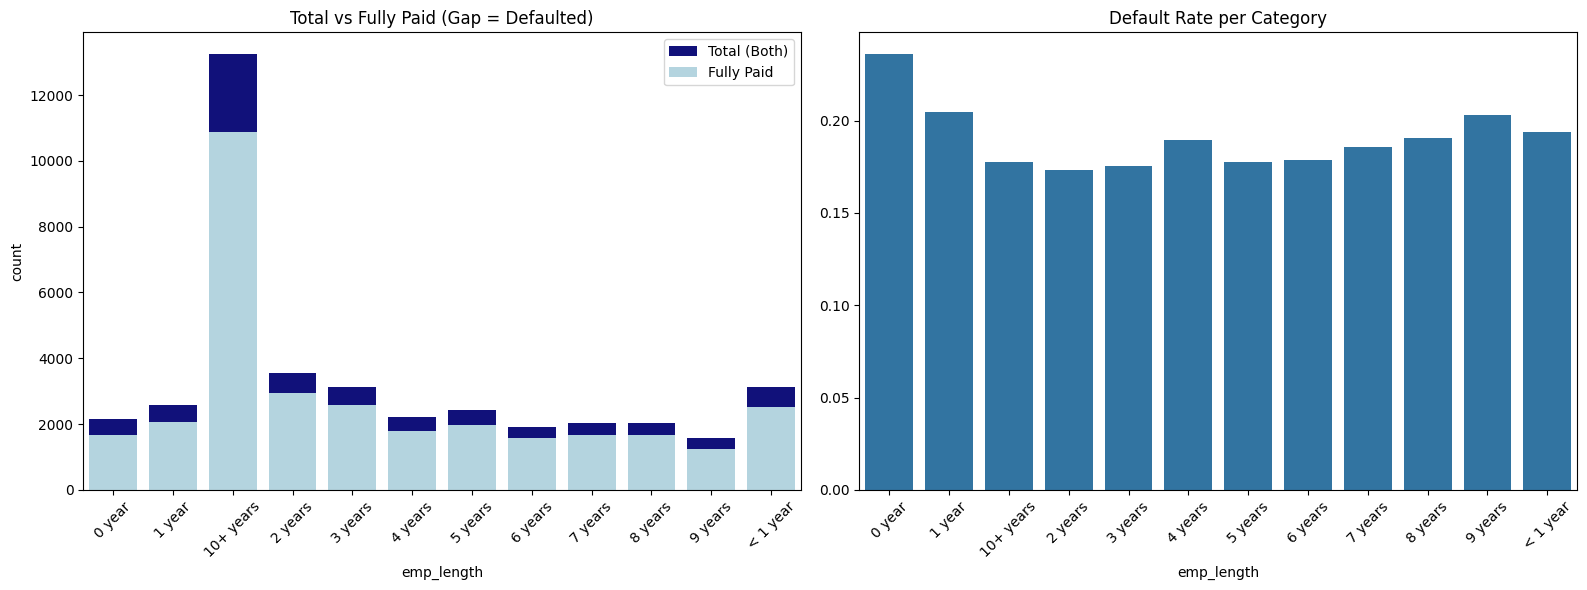

In [14]:
draw_plot("emp_length")

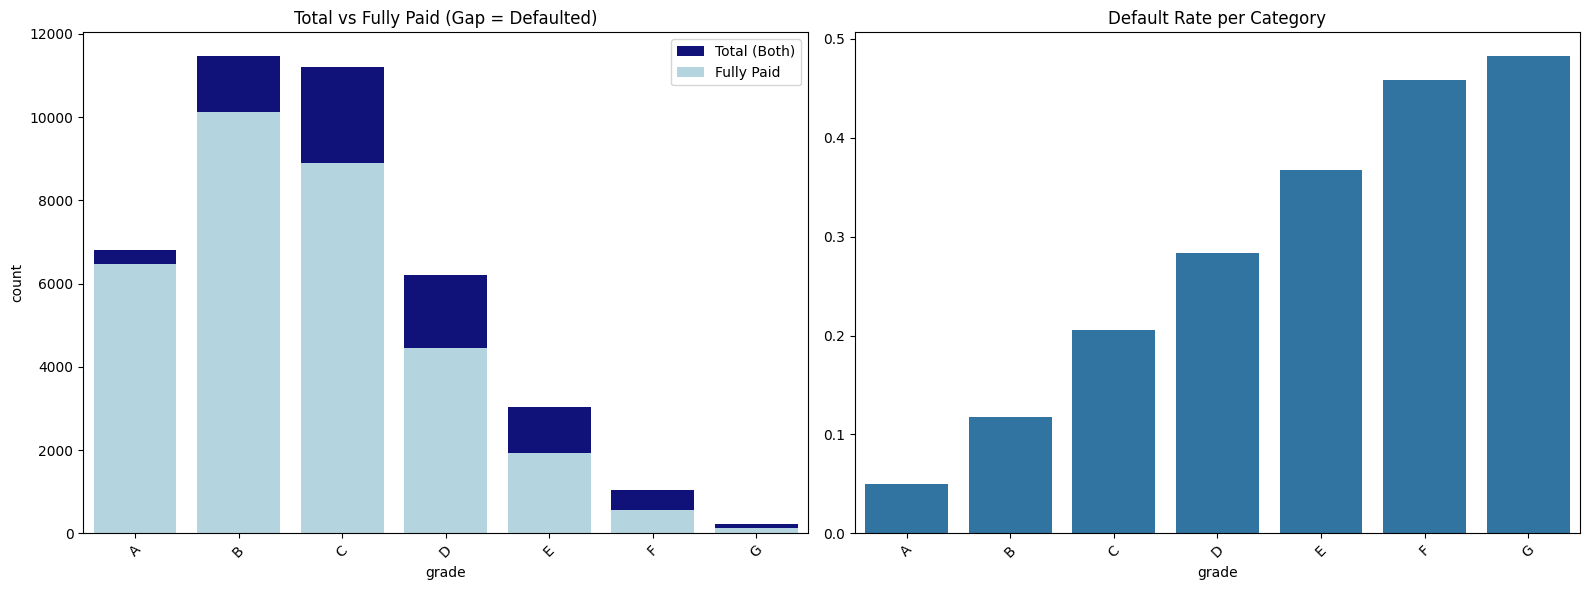

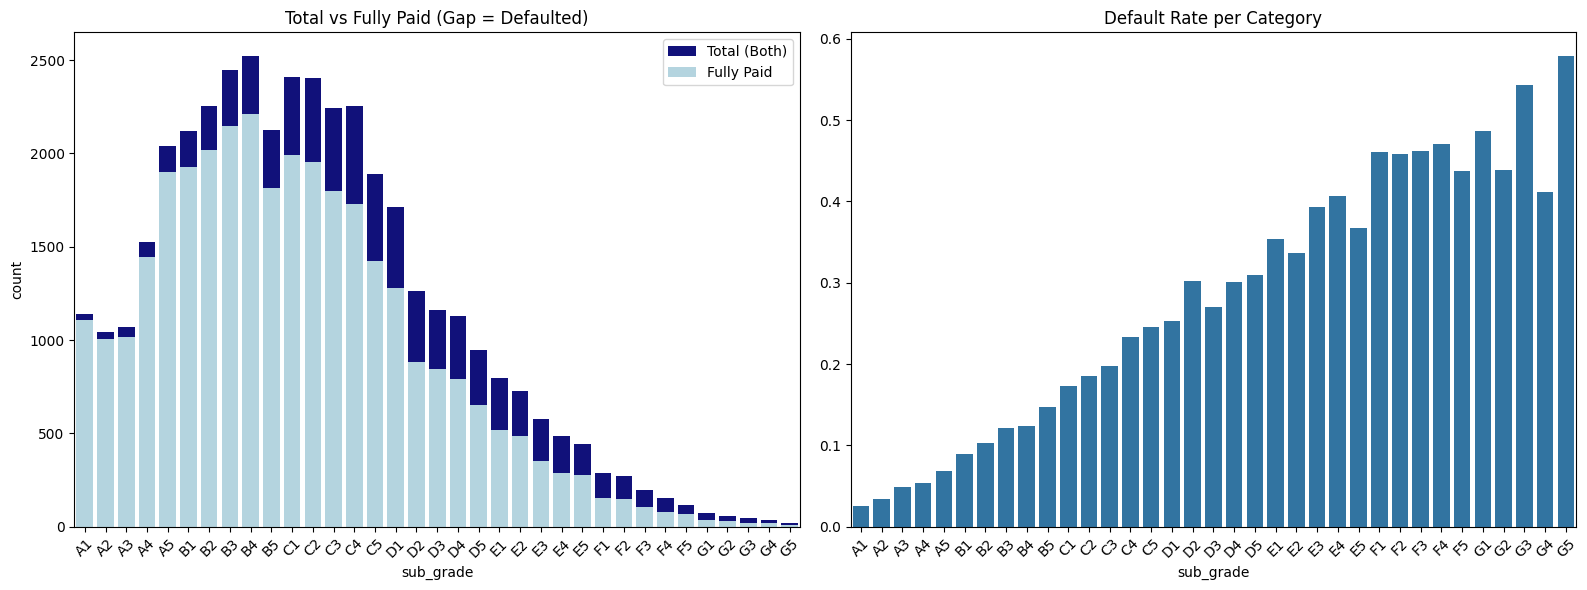

In [16]:
# for empy_length there isn't a strong correlation between employment length and loan status

draw_plot("grade")
draw_plot("sub_grade")

In [17]:
# both grade and sub_grade roughly gives the same information
# there is no need to keep both of them , since sub_grade is more precise we decided to drop grade
df.drop(columns=["grade"],inplace=True)

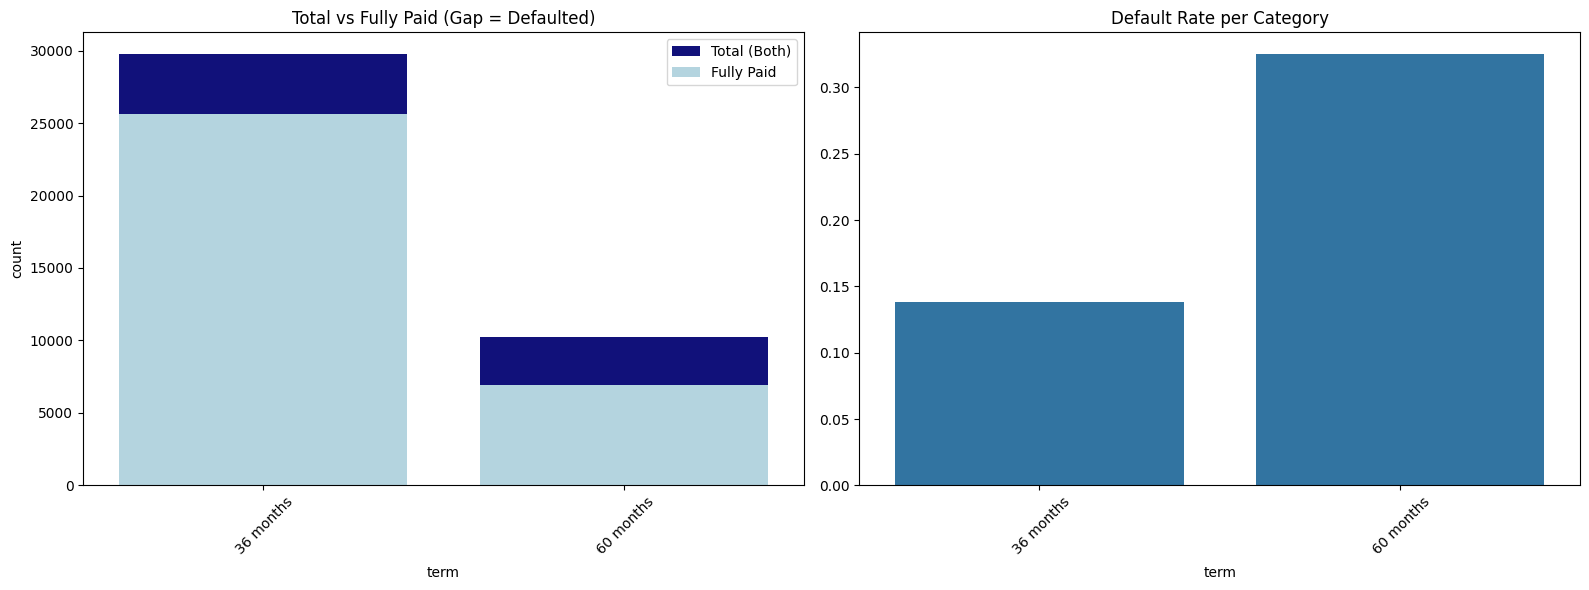

In [18]:
draw_plot("term")

In [19]:
# as it is seen in the graph ,the column term is the one of the key variables in the model

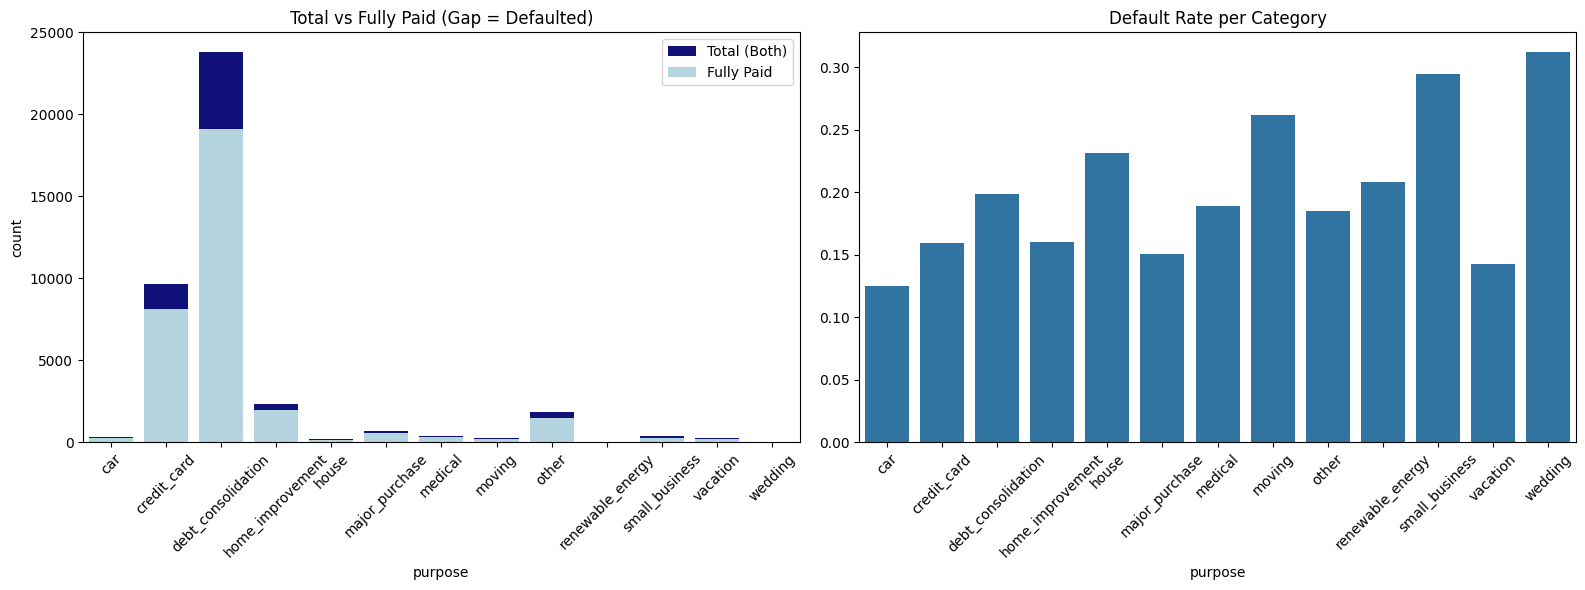

In [20]:
draw_plot("purpose")

In [21]:
# Purpose column gives some information about default rate
# loans that were taken for car/vacation purposes were paid back
# small-business loans weren't paid back.
# this column should be kept.

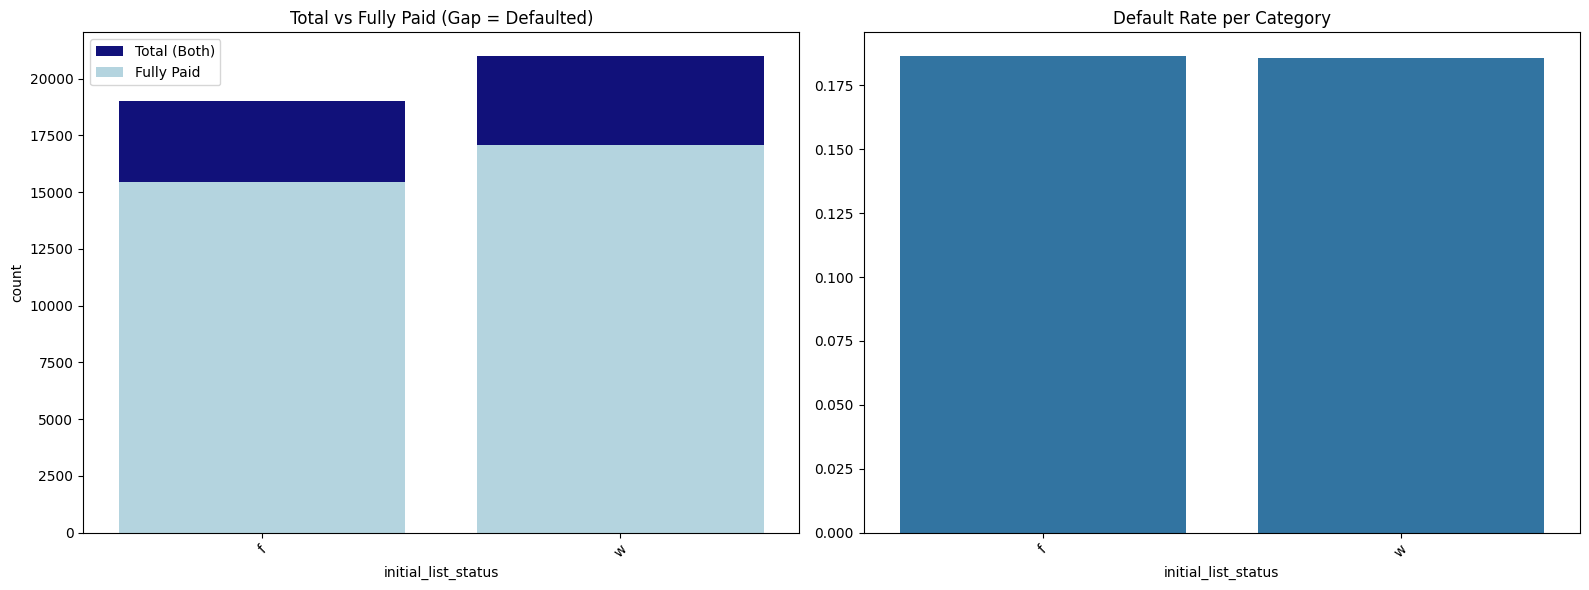

,count,mean,std,min,25%,50%,75%,max
initial_list_status,,,,,,,,
f,19008.0,0.813552,0.389478,0.0,1.0,1.0,1.0,1.0
w,20992.0,0.814263,0.388904,0.0,1.0,1.0,1.0,1.0


In [22]:
draw_plot("initial_list_status")
df.groupby("initial_list_status")["loan_status"].describe()

In [23]:
# since this column has no predictive power over loan status , this column can be removed.
df.drop(columns=["initial_list_status"],inplace=True)

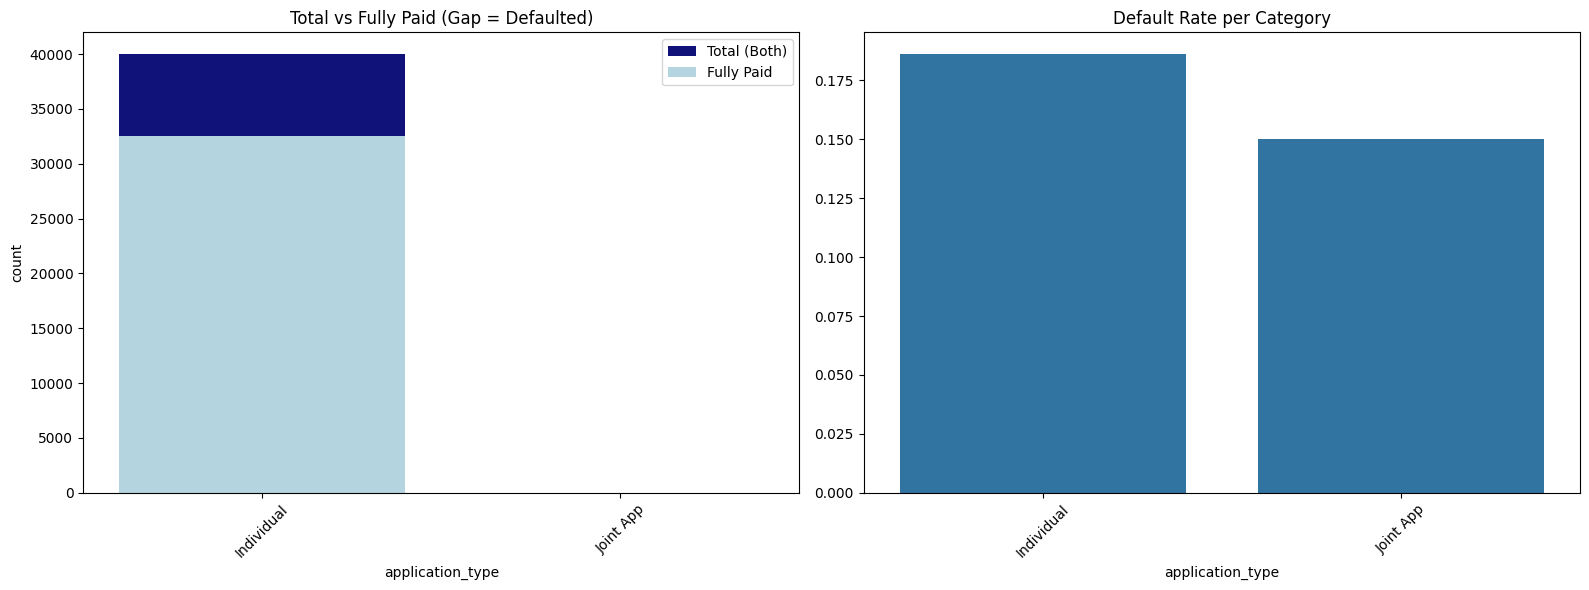

Counter({'Individual': 39980, 'Joint App': 20})

In [24]:
draw_plot("application_type")
Counter(df["application_type"])

In [25]:
# This column could be removed since one variable has significantly higher weight but for advanced model
# we decided to keep this. There is quite high default rate difference between two type of accounts.

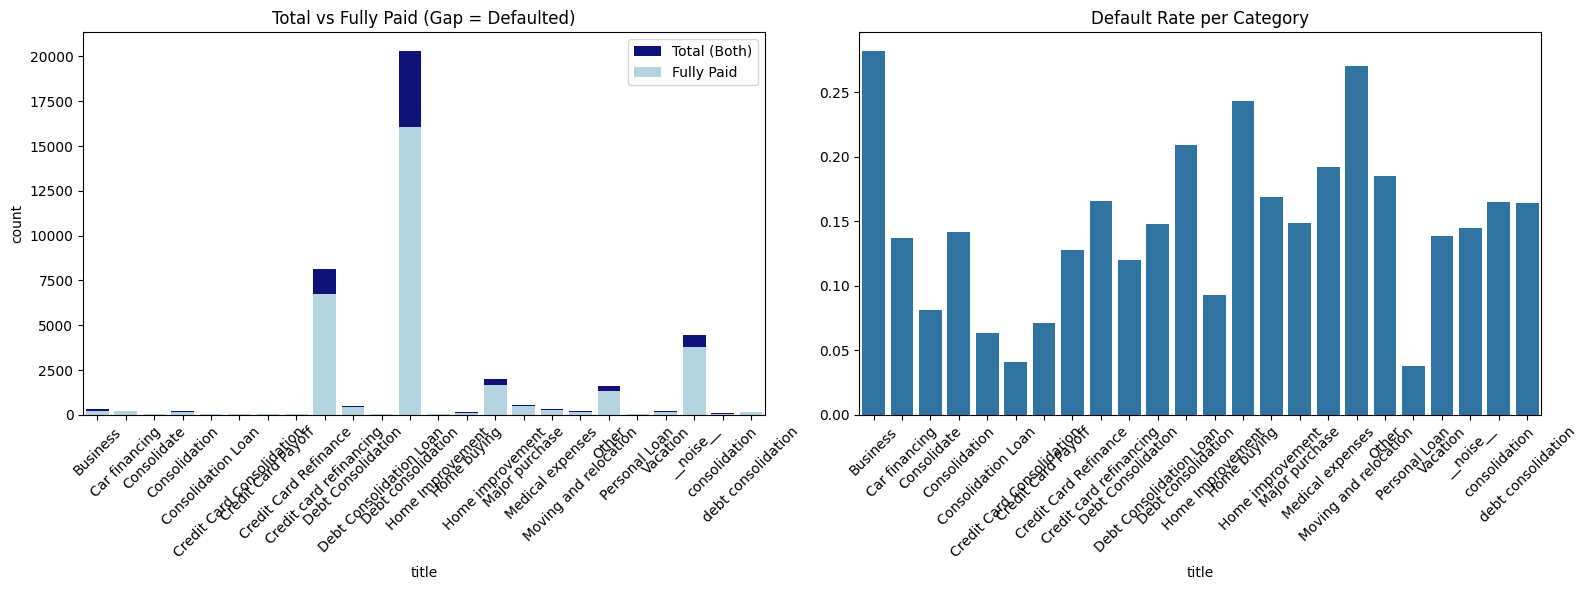

In [26]:
draw_plot("title")

In [27]:
# this column will have impact on model. should be kept.

In [28]:
# ENCODING

# helper functions for encoding

def writeUniques(colName):
    print(df[colName].unique())

def isEncoded(colName):
    if(df[colName].dtype == int): return True
    return False

In [29]:
def encode_sub_grade():
    if(isEncoded("sub_grade")):
        print("already encoded")
        return
    writeUniques("sub_grade")
    mapped_sub_grade = {
        "A1":35,
        "A2":34,
        "A3":33,
        "A4":32,
        "A5":31,
        "B1":30,
        "B2":29,
        "B3":28,
        "B4":27,
        "B5":26,
        "C1":25,
        "C2":24,
        "C3":23,
        "C4":22,
        "C5":21,
        "D1":20,
        "D2":19,
        "D3":18,
        "D4":17,
        "D5":16,
        "E1":15,
        "E2":14,
        "E3":13,
        "E4":12,
        "E5":11,
        "F1":10,
        "F2":9,
        "F3":8,
        "F4":7,
        "F5":6,
        "G1":5,
        "G2":4,
        "G3":3,
        "G4":2,
        "G5":1,
    }
    def applyMappedValues_subgrade(grade_value):
        return mapped_sub_grade[grade_value]
    df["sub_grade"] = df["sub_grade"].apply(applyMappedValues_subgrade)
    writeUniques("sub_grade")

encode_sub_grade()

['D1' 'A3' 'B3' 'D2' 'A5' 'F3' 'B5' 'C4' 'C5' 'C2' 'A4' 'B1' 'C1' 'E2'
 'D5' 'C3' 'D3' 'B4' 'D4' 'B2' 'E1' 'A1' 'A2' 'E4' 'E5' 'F5' 'E3' 'F4'
 'G4' 'G2' 'F2' 'F1' 'G1' 'G3' 'G5']
[20 33 28 19 31  8 26 22 21 24 32 30 25 14 16 23 18 27 17 29 15 35 34 12
 11  6 13  7  2  4  9 10  5  3  1]


In [30]:
def encode_term():
    if(isEncoded("term")):
        print("already encoded!")
        return
    writeUniques("term")
    mapped_term = {
        " 36 months":36,
        " 60 months":60
    }
    def applyMappedValues_term(term_value):
        return mapped_term[term_value]
    df["term"] = df["term"].apply(applyMappedValues_term)
    writeUniques("term")

encode_term()

[' 60 months' ' 36 months']
[60 36]


In [31]:
def encode_emp_length():
    if(isEncoded("emp_length")):
        print("already encoded!")
        return
    writeUniques("emp_length")
    mapped_emp_length = {
        "0 year":0,
        "< 1 year":1,
        "1 year":2,
        "2 years":3,
        "3 years":4,
        "4 years":5,
        "5 years":6,
        "6 years":7,
        "7 years":8,
        "8 years":9,
        "9 years":10,
        "10+ years":11
    }
    def apply_mapped_emp_length(employment_length):
        return mapped_emp_length[employment_length]
    df["emp_length"] = df["emp_length"].apply(apply_mapped_emp_length)
    writeUniques("emp_length")

encode_emp_length()

['9 years' '10+ years' '3 years' '6 years' '1 year' '5 years' '7 years'
 '8 years' '2 years' '0 year' '< 1 year' '4 years']
[10 11  4  7  2  6  8  9  3  0  1  5]


In [32]:
# Columns that are used in ONE-HOT Label Encoding
unique_counts = df.nunique(dropna=False).sort_values(ascending=False)

# Print the results
for col, count in unique_counts.items():
    if df[col].dtype == object:
        print(f"{col}-{count}-{df[col].dtype}")

earliest_cr_line-590-object
emp_title-69-object
addr_state-49-object
issue_d-36-object
title-24-object
purpose-13-object
home_ownership-3-object
verification_status-3-object
application_type-2-object


In [33]:
# One-Hot Encoding
# if we didn't supprass nonises for categorical columns, here we would create too many columns
columns_one_hot_encode = []
for col in df.columns:
    if(df[col].dtype == object):
        columns_one_hot_encode.append(col)


df_encoded = pd.get_dummies(df,columns = columns_one_hot_encode,dtype=int,drop_first=False)
df_encoded.shape

(40000, 846)

In [34]:
# LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Target Variable
y = df_encoded['loan_status']
# Features
X = df_encoded.drop('loan_status', axis=1)
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Train
model = LogisticRegression(
    C=0.1, 
    penalty='l2', 
    solver='liblinear', 
    class_weight= {0:1.25, 1:1},  #our aim is to minimum False Positive
    max_iter=5000
)
model.fit(X_train_scaled, y_train)
# Evaluate
predictions = model.predict(X_test_scaled)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.46      0.19      0.27      1489
           1       0.84      0.95      0.89      6511

    accuracy                           0.81      8000
   macro avg       0.65      0.57      0.58      8000
weighted avg       0.77      0.81      0.77      8000



In [35]:
# %81 accuracy
# We changed penaly for defaults
# in order to check standart accuracy class_weight parameter could be changed with "blanced"

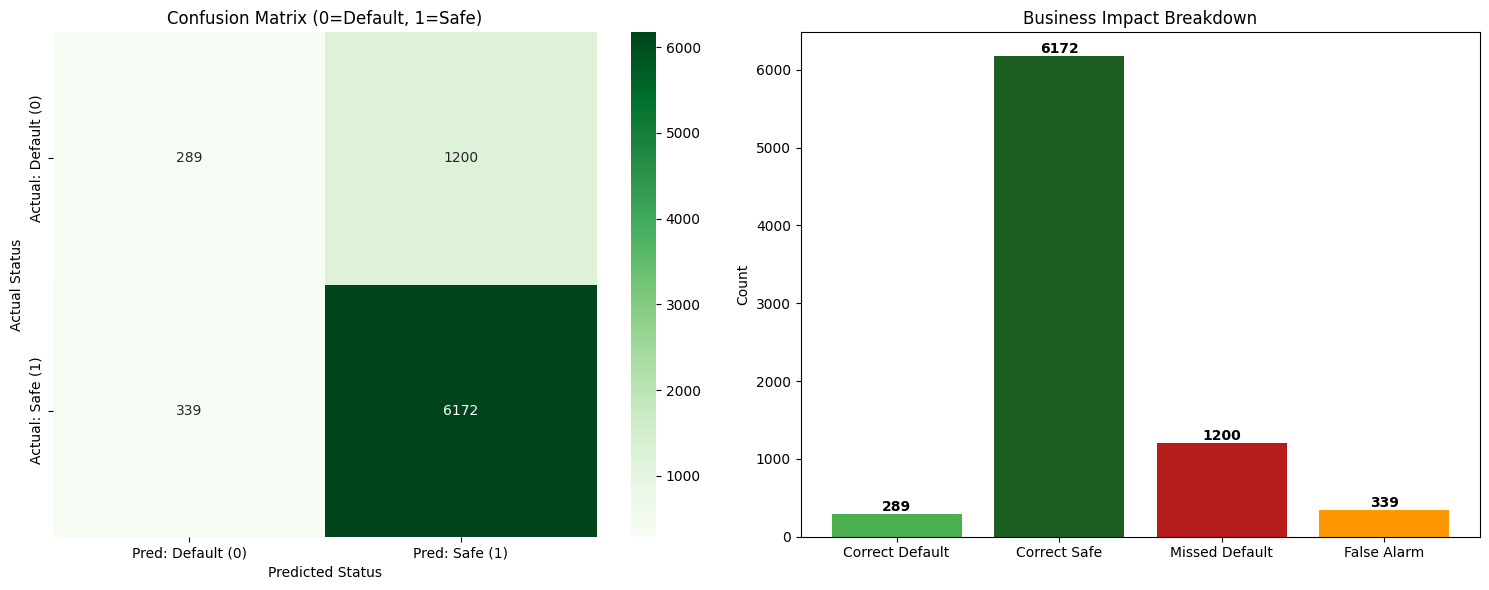

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def showResult(prediction, actual):
    # With 0 = Default and 1 = Safe:
    cm = confusion_matrix(actual, prediction)
    
    # Mapping the matrix based on the 0=Default 1-Correct logic
    correct_default = cm[0, 0]
    missed_default  = cm[0, 1] # The "Dangerous" error
    false_alarm     = cm[1, 0] # The "Lost Revenue" error
    correct_safe    = cm[1, 1]
    
    plt.figure(figsize=(15, 6))
    
    # 1. Heatmap with your specific labels
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=True,
                xticklabels=['Pred: Default (0)', 'Pred: Safe (1)'],
                yticklabels=['Actual: Default (0)', 'Actual: Safe (1)'])
    plt.title('Confusion Matrix (0=Default, 1=Safe)')
    plt.ylabel('Actual Status')
    plt.xlabel('Predicted Status')
    
    # 2. Bar Chart for Clear Breakdown
    plt.subplot(1, 2, 2)
    categories = ['Correct Default', 'Correct Safe', 'Missed Default', 'False Alarm']
    values = [correct_default, correct_safe, missed_default, false_alarm]
    # Colors: Dark Green for hits, Orange/Red for misses
    colors = ['#4caf50', '#1b5e20', '#b71c1c', '#ff9800'] 
    
    bars = plt.bar(categories, values, color=colors)
    plt.title('Business Impact Breakdown')
    plt.ylabel('Count')
    
    # Add numbers on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), 
                 ha='center', va='bottom', fontweight='bold')
        
    plt.tight_layout()
    plt.show()


showResult(predictions, y_test)

In [37]:
model_2 = LogisticRegression(
    C=0.1, 
    penalty='l2', 
    solver='liblinear', 
    class_weight= {0:4, 1:1},  #penalise false positive significantly
    max_iter=5000
)
model_2.fit(X_train_scaled, y_train)
# Evaluate
predictions_2 = model_2.predict(X_test_scaled)
print(classification_report(y_test, predictions_2))

              precision    recall  f1-score   support

           0       0.32      0.60      0.41      1489
           1       0.88      0.70      0.78      6511

    accuracy                           0.68      8000
   macro avg       0.60      0.65      0.60      8000
weighted avg       0.78      0.68      0.71      8000



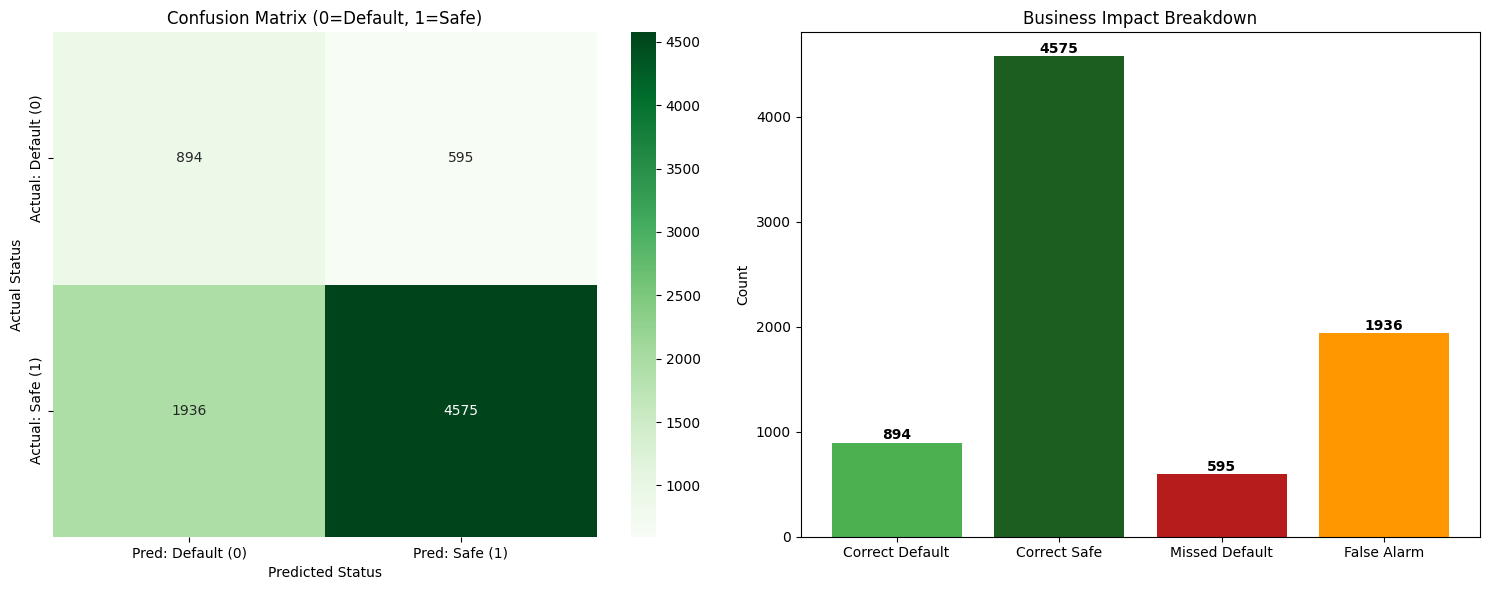

In [38]:
showResult(predictions_2,y_test)

In [39]:
# first one %81 accuracy but relatively high False Positive , second one %70 accuracy but significantly low False Positive

In [40]:
# TODO

# model_randomforest -> showResult  and interpretation
# model_neural network -> showResult and interpretation
# ...

# then show every result in a graph for comparasion

# Finish

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.44      0.12      0.19      1489
           1       0.83      0.96      0.89      6511

    accuracy                           0.81      8000
   macro avg       0.64      0.54      0.54      8000
weighted avg       0.76      0.81      0.76      8000



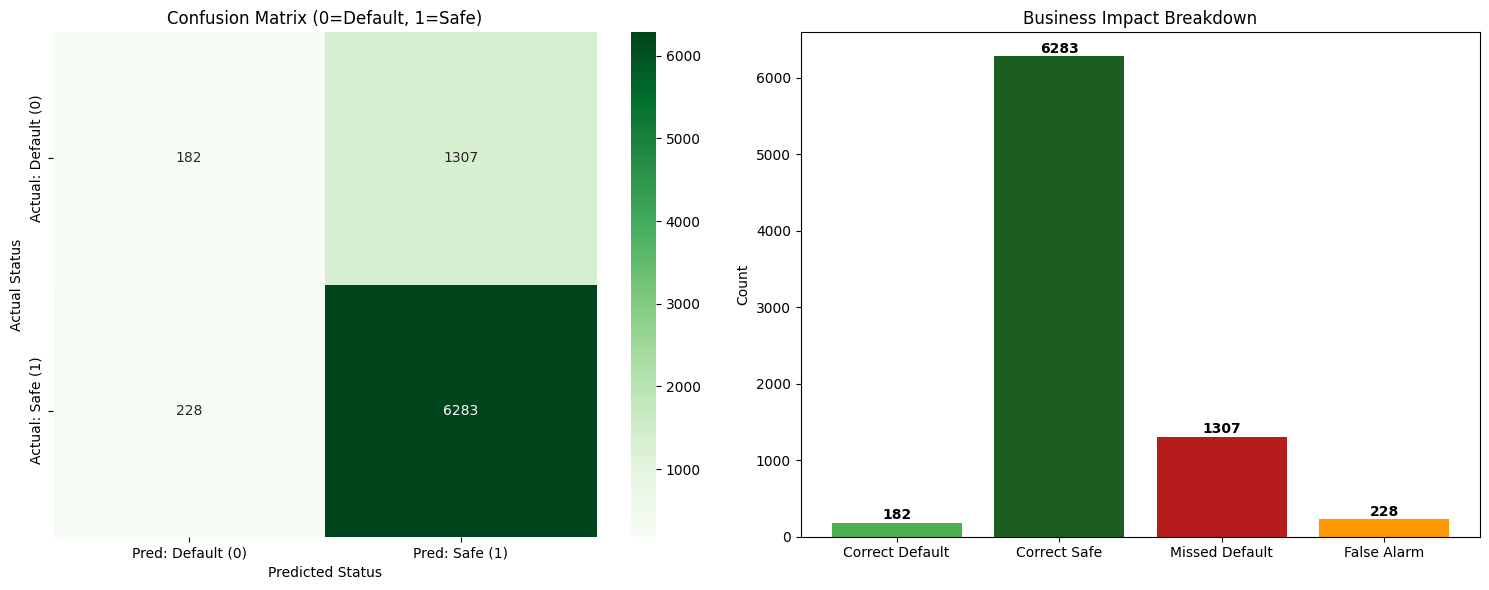

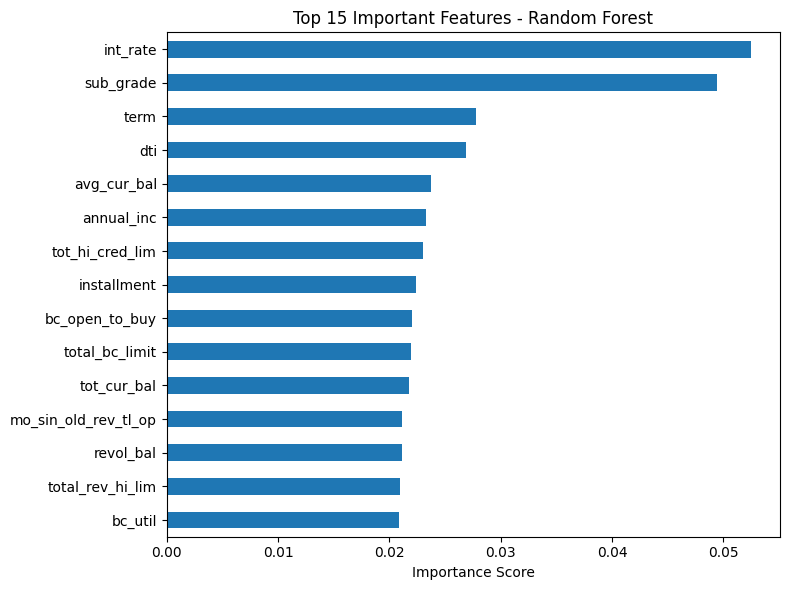

In [42]:
# RANDOM FOREST MODEL (SEPARATE PIPELINE)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

#Prepare Data (Using df_encoded)

y_rf = df_encoded['loan_status']
X_rf = df_encoded.drop('loan_status', axis=1)

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, 
    test_size=0.2, 
    stratify=y_rf, 
    random_state=64
)

#Train Random Forest
model_randomforest = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight={0:4, 1:1},   # Penalize missing defaults
    random_state=42,
    n_jobs=-1
)

model_randomforest.fit(X_train_rf, y_train_rf)

#Evaluate

predictions_rf = model_randomforest.predict(X_test_rf)

print("Random Forest Classification Report")
print(classification_report(y_test_rf, predictions_rf))

#Confusion Matrix Visualization

showResult(predictions_rf, y_test_rf)

#Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model_randomforest.feature_importances_,
    index=X_rf.columns
).sort_values(ascending=False)

# Show Top 15 Important Features
top_features = feature_importance.head(15)

plt.figure(figsize=(8,6))
top_features.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

Optimal Threshold: 0.717


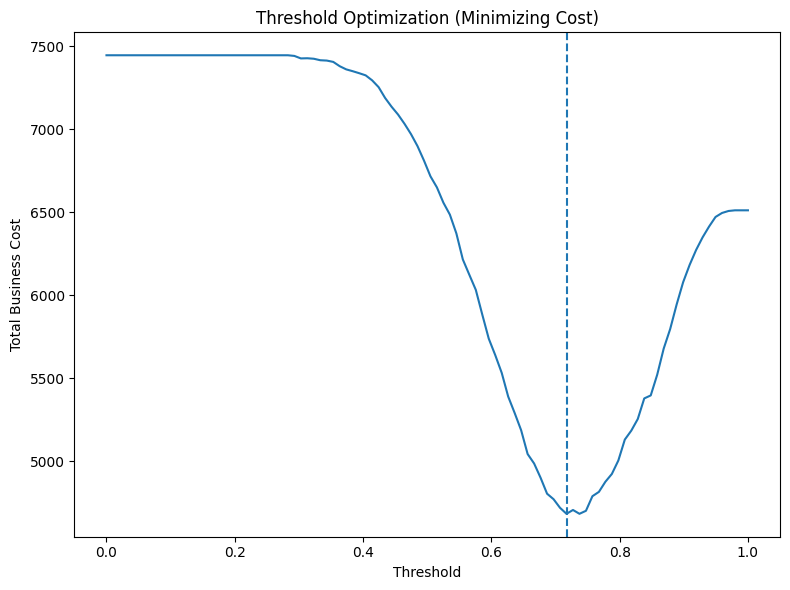

Confusion Matrix with Optimized Threshold:


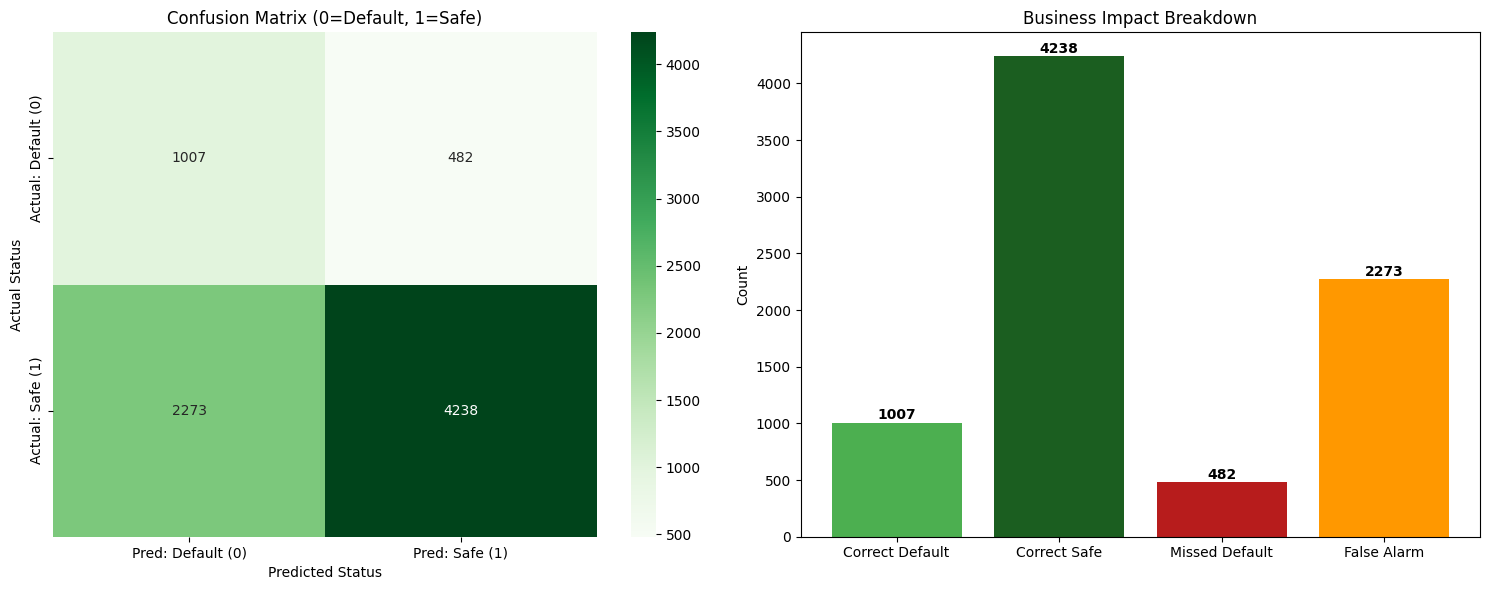

In [47]:
# ==========================================
# THRESHOLD OPTIMIZATION - RANDOM FOREST
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ------------------------------------------
# 1. Get probabilities
# ------------------------------------------

rf_probs = model_randomforest.predict_proba(X_test_rf)[:, 1]

# ------------------------------------------
# 2. Define cost function
# ------------------------------------------
# Assume:
# Missing Default (False Negative for class 0) = 5x worse
# False Alarm (Reject safe loan) = 1x

cost_fn = 5
cost_fp = 1

thresholds = np.linspace(0, 1, 100)
costs = []

for t in thresholds:
    preds = (rf_probs >= t).astype(int)
    cm = confusion_matrix(y_test_rf, preds)
    
    # 0 = Default, 1 = Safe
    missed_default = cm[0, 1]  # dangerous
    false_alarm = cm[1, 0]     # lost revenue
    
    total_cost = cost_fn * missed_default + cost_fp * false_alarm
    costs.append(total_cost)

#Find Best Threshold
best_threshold = thresholds[np.argmin(costs)]
print("Optimal Threshold:", round(best_threshold, 3))

#Plot Cost vs Threshold
plt.figure(figsize=(8,6))
plt.plot(thresholds, costs)
plt.axvline(best_threshold, linestyle='--')
plt.xlabel("Threshold")
plt.ylabel("Total Business Cost")
plt.title("Threshold Optimization (Minimizing Cost)")
plt.tight_layout()
plt.show()
#Evaluate Using Optimal Threshold
optimized_preds = (rf_probs >= best_threshold).astype(int)

print("Confusion Matrix with Optimized Threshold:")
showResult(optimized_preds, y_test_rf)

100%|===================| 998/1000 [06:10<00:00]        

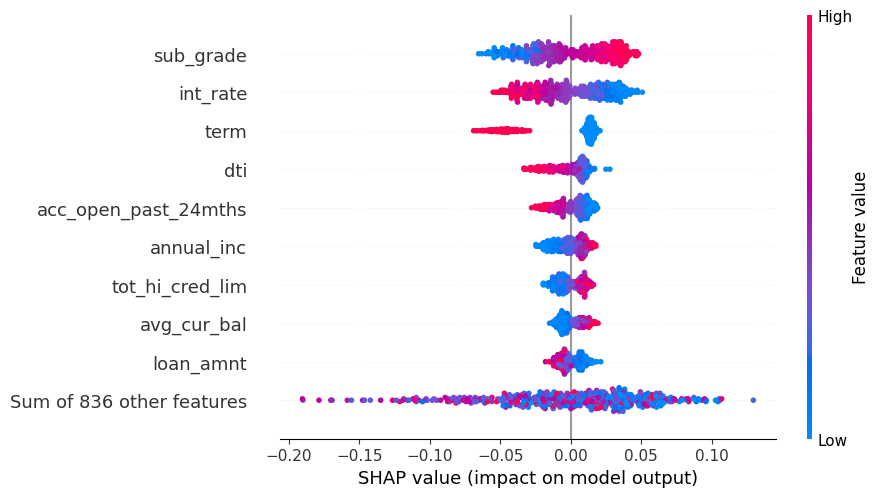

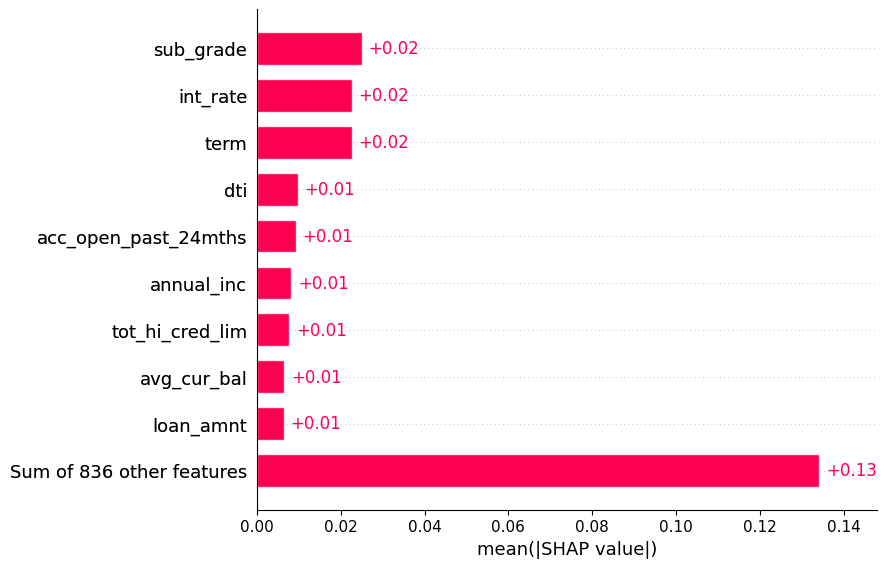

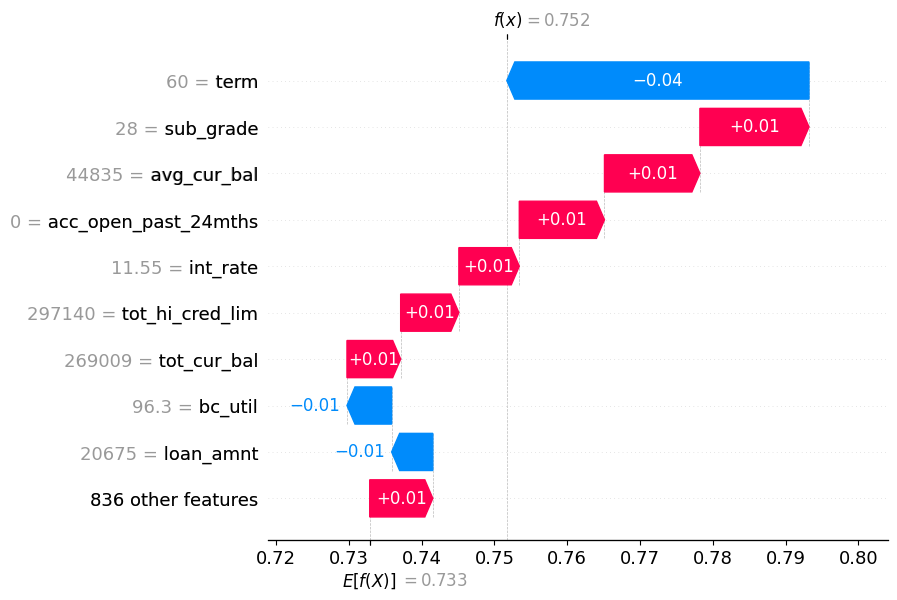

In [43]:
# SHAP EXPLAINABILITY - RANDOM FOREST (FIXED)

import shap
import matplotlib.pyplot as plt

# Create explainer
explainer = shap.Explainer(model_randomforest, X_train_rf)

# Sample data
X_sample = X_test_rf.sample(500, random_state=42)

# Get SHAP values
shap_values = explainer(X_sample)

# Select class 1 (Safe) or class 0 (Default)

shap_values_class1 = shap_values[:, :, 1]   # Class 1
# shap_values_class0 = shap_values[:, :, 0] # If you want Default

#Beeswarm Plot
shap.plots.beeswarm(shap_values_class1)

#Bar Plot
shap.plots.bar(shap_values_class1)

#Waterfall (Single Prediction)
shap.plots.waterfall(shap_values_class1[0])

Neural Network Classification Report
              precision    recall  f1-score   support

           0       0.29      0.24      0.26      1489
           1       0.83      0.86      0.85      6511

    accuracy                           0.75      8000
   macro avg       0.56      0.55      0.55      8000
weighted avg       0.73      0.75      0.74      8000



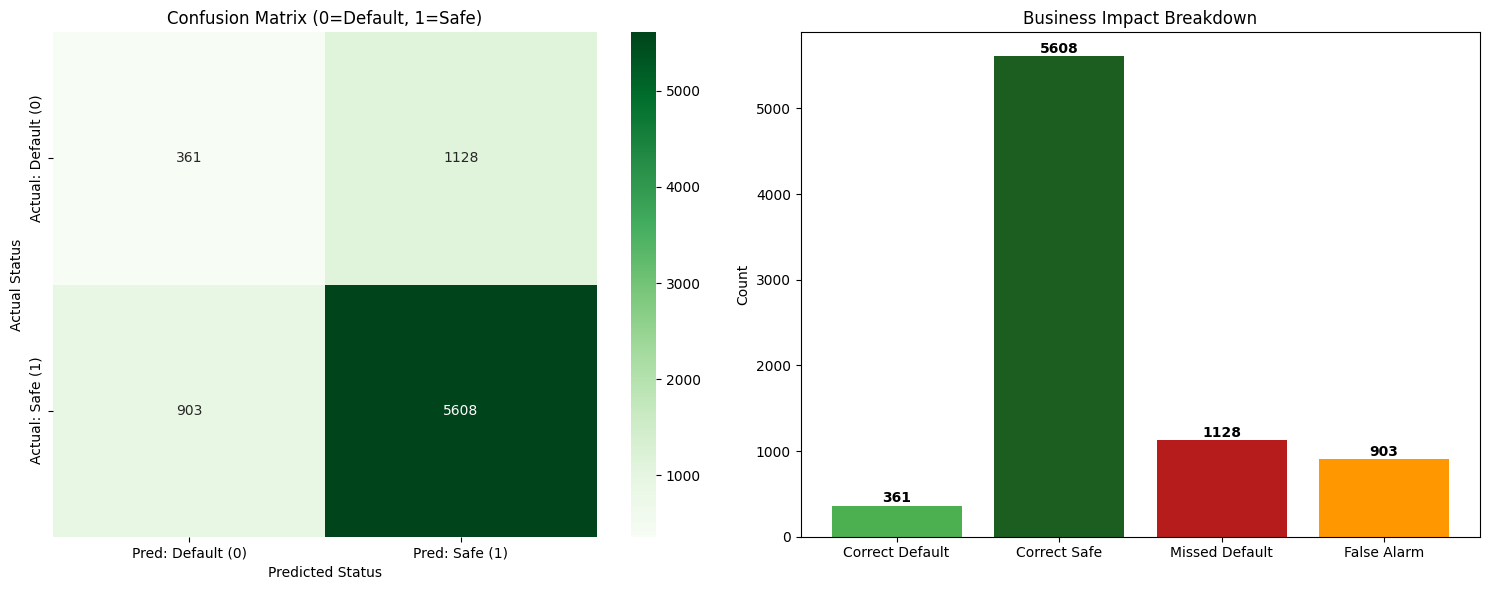

In [45]:
# NEURAL NETWORK MODEL (SEPARATE PIPELINE)

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

#Prepare Data

y_nn = df_encoded['loan_status']
X_nn = df_encoded.drop('loan_status', axis=1)

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y_nn,
    test_size=0.2,
    stratify=y_nn,
    random_state=42
)

#Feature Scaling (IMPORTANT for NN)

scaler_nn = StandardScaler()
X_train_nn_scaled = scaler_nn.fit_transform(X_train_nn)
X_test_nn_scaled = scaler_nn.transform(X_test_nn)

#Build Neural Network

model_neuralnetwork = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 hidden layers
    activation='relu',
    solver='adam',
    alpha=0.001,                   # L2 regularization
    batch_size=256,
    learning_rate='adaptive',
    max_iter=200,
    random_state=42
)

#Train

model_neuralnetwork.fit(X_train_nn_scaled, y_train_nn)

#Evaluate
predictions_nn = model_neuralnetwork.predict(X_test_nn_scaled)

print("Neural Network Classification Report")
print(classification_report(y_test_nn, predictions_nn))

#Confusion Matrix Visualization
showResult(predictions_nn, y_test_nn)

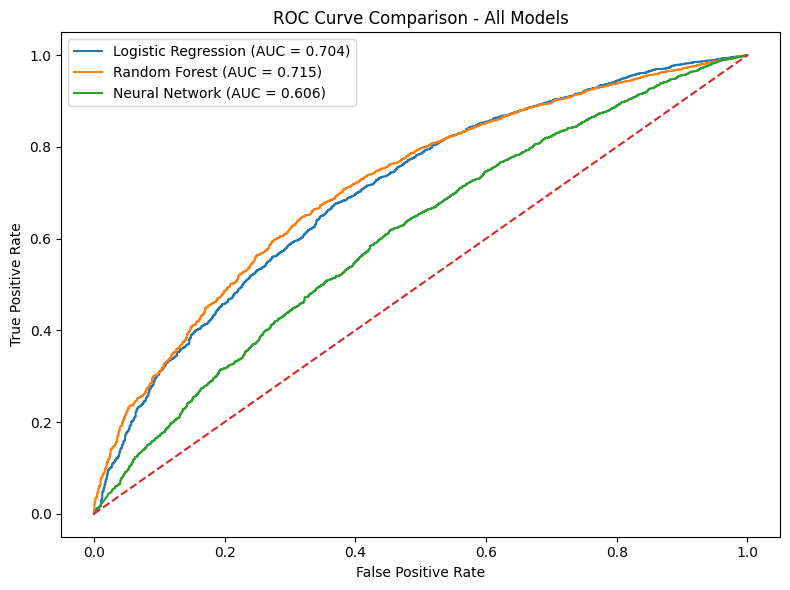

In [46]:
# ROC CURVE COMPARISON - ALL 3 MODELS

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

#Get Probability Scores

# Logistic Regression
log_probs = model.predict_proba(X_test_scaled)[:, 1]

# Random Forest
rf_probs = model_randomforest.predict_proba(X_test_rf)[:, 1]

# Neural Network
nn_probs = model_neuralnetwork.predict_proba(X_test_nn_scaled)[:, 1]

#Compute ROC Curves

fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, rf_probs)
fpr_nn, tpr_nn, _ = roc_curve(y_test_nn, nn_probs)

# AUC Scores
auc_log = roc_auc_score(y_test, log_probs)
auc_rf = roc_auc_score(y_test_rf, rf_probs)
auc_nn = roc_auc_score(y_test_nn, nn_probs)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.3f})')

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - All Models")
plt.legend()
plt.tight_layout()
plt.show()